Dieser Code trainiert und evaluiert zwei LSTM Modelle mit der Vektorisierung Bag of Words anhand dieses Datensatzes:

@inproceedings{tonneau-etal-2024-languages,

    title = "From Languages to Geographies: Towards Evaluating Cultural Bias in Hate Speech Datasets",

    author = {Tonneau, Manuel  and
      Liu, Diyi  and
      Fraiberger, Samuel  and
      Schroeder, Ralph  and
      Hale, Scott  and
      Röttger, Paul},
    editor = {Chung, Yi-Ling  and
      Talat, Zeerak  and
      Nozza, Debora  and
      Plaza-del-Arco, Flor Miriam  and
      Röttger, Paul  and
      Mostafazadeh Davani, Aida  and
      Calabrese, Agostina},
    
    booktitle = "Proceedings of the 8th Workshop on Online Abuse and Harms (WOAH 2024)",
    month = jun,
    year = "2024",
    address = "Mexico City, Mexico",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2024.woah-1.23",
    pages = "283--311",
    abstract = "Perceptions of hate can vary greatly across cultural contexts.
    Hate speech (HS) datasets, however, have traditionally been developed by
    language. This hides potential cultural biases, as one language may be
    spoken in different countries home to different cultures. In this work, we
    evaluate cultural bias in HS datasets by leveraging two interrelated
    cultural proxies: language and geography. We conduct a systematic survey
    of HS datasets in eight languages and confirm past findings on their
    English-language bias, but also show that this bias has been steadily
    decreasing in the past few years. For three geographically-widespread
    languages{---}English, Arabic and Spanish{---}we then leverage
    geographical metadata from tweets to approximate geo-cultural contexts by
    pairing language and country information. We find that HS datasets for
    these languages exhibit a strong geo-cultural bias, largely
    overrepresenting a handful of countries (e.g., US and UK for English)
    relative to their prominence in both the broader social media population
    and the general population speaking these languages. Based on these
    findings, we formulate recommendations for the creation of future HS
    datasets.",}
Die Vektorisierung erfoglt über Bag of Words.



In [1]:
 import pandas as pd
 import matplotlib.pyplot  as plt
 import seaborn as sns
 import numpy as np
 import sklearn
 import sklearn.metrics as metrics
 from tensorflow.keras.preprocessing.text import Tokenizer
 from tensorflow.keras.preprocessing.sequence import pad_sequences
 from tensorflow.keras.models import Sequential
 from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Dateninitialisierung

In [3]:
df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/de_hf_112024.csv",sep=",",engine="python",on_bad_lines="skip",encoding="utf-8")
df.head()


,text,labels,source,dataset,nb_annotators
0,gleich an die wand stellen und erschiessen..,1.0,Facebook,Bretschneider,2.0
1,nicht dass ich der Grundbotschaft dieses Post'...,0.0,Facebook,Bretschneider,2.0
2,"Das mit dem ""an die Wand stellen und erschiessen""",0.0,Facebook,Bretschneider,2.0
3,"Seit dem ""an die Wand stellen und erschiessen""...",0.0,Facebook,Bretschneider,2.0
4,Ja ja die Kriminelle Heimatpartei FPÖ von Kind...,0.0,Facebook,Bretschneider,2.0


In [4]:
df["labels"].isna().sum()
df[df["labels"].isna()]


,text,labels,source,dataset,nb_annotators
2519,Das macht Angst....,NaN,None,None,NaN


In [5]:
df=df.dropna(subset=["labels"])

In [6]:
df["labels"].isna().sum()

np.int64(0)

# Datensatzaufteilung

In [7]:
from sklearn.model_selection import train_test_split
X=df["text"]
y=df["labels"].astype(int)

In [8]:
#TRAIN /TEST
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
#TRAIN / VALIDATION
X_train, X_val, y_train, y_val = train_test_split( X_train, y_train, test_size=0.1, random_state=42)

In [9]:
import numpy as np

print("Train:", np.bincount(y_train))
print("Val:", np.bincount(y_val))
print("Test:", np.bincount(y_test))


Train: [31827  4563]
Val: [3548  496]
Test: [8871 1238]


**Tokenisierung**

In [10]:
tokenizer = Tokenizer(num_words=50000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [11]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_val_sequences = tokenizer.texts_to_sequences(X_val)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

maxlen=175
X_train_padded = pad_sequences(X_train_sequences, maxlen=maxlen, padding='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=maxlen, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=maxlen, padding='post')

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


#LSTM Modell Einfach

In [13]:
modelSequential=Sequential()
modelSequential.add(Embedding(input_dim=50000, output_dim=128, input_length=maxlen))
modelSequential.add(LSTM(128, dropout=0.3, recurrent_dropout=0.3))
modelSequential.add(Dropout(0.3))
modelSequential.add(Dense(1,activation="sigmoid"))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
modelSequential.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)
historySequenz=modelSequential.fit(
    X_train_padded, y_train,
    validation_data=(X_val_padded, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[es]
)

Epoch 1/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 498s 864ms/step - accuracy: 0.8743 - loss: 0.3827 - val_accuracy: 0.8773 - val_loss: 0.3723
Epoch 2/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 424s 728ms/step - accuracy: 0.8746 - loss: 0.3796 - val_accuracy: 0.8773 - val_loss: 0.3728
Epoch 3/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 415s 729ms/step - accuracy: 0.8746 - loss: 0.3795 - val_accuracy: 0.8773 - val_loss: 0.3724


**Validierung**

In [15]:
y_val_proba=modelSequential.predict(X_val_padded).flatten()
y_valpred=(y_val_proba>0.5).astype(int)

#wahrscheinlichkeit speichern
with open("lstm_validierung_sequentiel.txt","w") as fd:
  for text, label, proba in zip(X_val, y_val, y_val_proba):
    fd.write(f"Text: {text}\n")
    fd.write(f"Label: {label}\n")
    fd.write(f"Wahrscheinlichkeit Hasskommentar: {proba}\n")
    fd.write("\n"*4)


#Klassifikationsschwellen
schwellen=np.arange(0.0,1.01,0.01)
beste_schwelle=0
bester_f1=0
for t in schwellen:
  y_val_pred_schwelle=(y_val_proba>t).astype(int)
  f1=metrics.f1_score(y_val,y_val_pred_schwelle)
  if f1>bester_f1:
    bester_f1=f1
    beste_schwelle=t
    print(f"Beste Schwelle: {beste_schwelle}\n")
    print(f"Beste F1-Score: {bester_f1}\n")

print(f"Beste Schwellenwert: {beste_schwelle}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step
Beste Schwelle: 0.0

Beste F1-Score: 0.2185022026431718

Beste Schwellenwert: 0.0


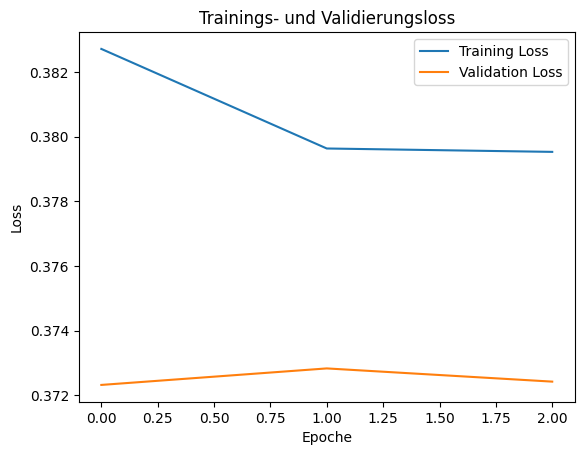

In [16]:
plt.plot(historySequenz.history['loss'], label='Training Loss')
plt.plot(historySequenz.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()
plt.title("Trainings- und Validierungsloss")
plt.show()

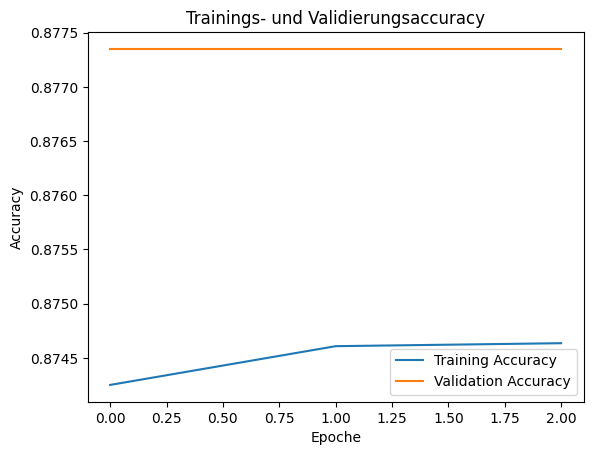

In [17]:
plt.plot(historySequenz.history['accuracy'], label='Training Accuracy')
plt.plot(historySequenz.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Trainings- und Validierungsaccuracy")
plt.show()

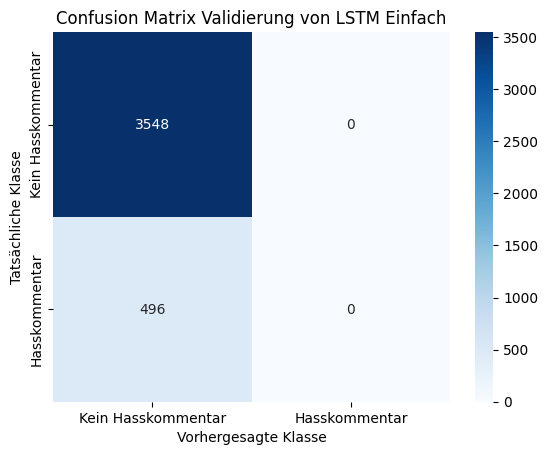

In [18]:
# Confusion Matrix

cm = metrics.confusion_matrix(y_val, y_valpred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar","Hasskommentar"],
    yticklabels=["Kein Hasskommentar","Hasskommentar"]
)
plt.title("Confusion Matrix Validierung von LSTM Einfach")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [19]:
# accuracy
vaccuracy = metrics.accuracy_score(y_val, y_valpred)
# precision
vprecision = metrics.precision_score(y_val, y_valpred)
# recall
vrecall = metrics.recall_score(y_val, y_valpred)
# f1-score
vf1=metrics.f1_score(y_val, y_valpred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_val, y_valpred).ravel()
vspecificity = tn/(tn+fp)
# macro recall
vmacro_recall=metrics.recall_score(y_val, y_valpred, average='macro')
# macro f1-score
vmacro_f1=metrics.f1_score(y_val, y_valpred, average='macro')

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
print("Accuracy: ", vaccuracy)
print("Precision: ", vprecision)
print("Recall: ", vrecall)
print("Specificity: ", vspecificity)
print("F1-Score: ", vf1)
print("Macro Recall: ", vmacro_recall)
print("Macro F1-Score: ", vmacro_f1)

Accuracy:  0.8773491592482691
Precision:  0.0
Recall:  0.0
Specificity:  1.0
F1-Score:  0.0
Macro Recall:  0.5
Macro F1-Score:  0.4673340358271865


**Evaluation Testen Standardschwelle**



In [21]:
y_pred=(modelSequential.predict(X_test_padded)>0.5).astype(int)
#print(classification_report(y_test,y_pred))

316/316 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step


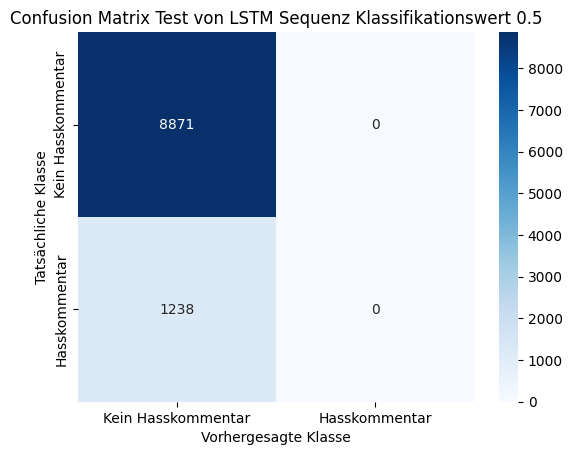

In [22]:
# Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar","Hasskommentar"],
    yticklabels=["Kein Hasskommentar","Hasskommentar"]
)
plt.title("Confusion Matrix Test von LSTM Sequenz Klassifikationswert 0.5")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [23]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
# precision
precision = metrics.precision_score(y_test, y_pred)
# recall
recall = metrics.recall_score(y_test, y_pred)
# f1-score
f1=metrics.f1_score(y_test, y_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test, y_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_pred, average='macro')

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.877534869917895
Precision:  0.0
Recall:  0.0
Specificity:  1.0
F1-Score:  0.0
Macro Recall:  0.5
Macro F1-Score:  0.46738672286617494


In [ ]:
#Modell speichern
import joblib
joblib.dump(modelSequential,"/content/drive/MyDrive/Colab Notebooks/LSTM_einfach_model_normal.plk")

['/content/drive/MyDrive/Colab Notebooks/LSTM_einfach_model_normal.plk']

**optimale Schwelle**

In [25]:
y_pred=(modelSequential.predict(X_test_padded)>beste_schwelle).astype(int)
#print(classification_report(y_test,y_pred))

316/316 ━━━━━━━━━━━━━━━━━━━━ 27s 84ms/step


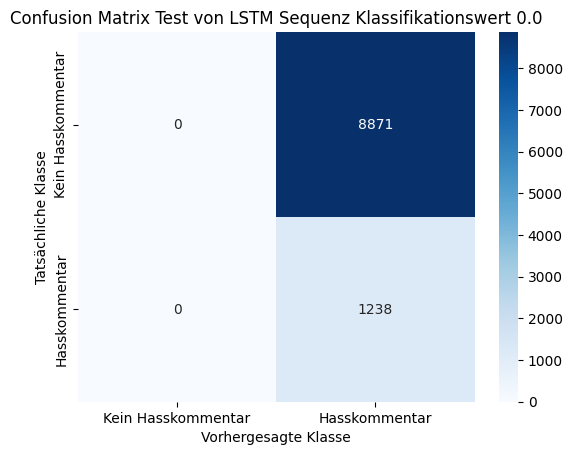

In [26]:
# Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar","Hasskommentar"],
    yticklabels=["Kein Hasskommentar","Hasskommentar"]
)
plt.title(f"Confusion Matrix Test von LSTM Sequenz Klassifikationswert {beste_schwelle}")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [27]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
# precision
precision = metrics.precision_score(y_test, y_pred)
# recall
recall = metrics.recall_score(y_test, y_pred)
# f1-score
f1=metrics.f1_score(y_test, y_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test, y_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_pred, average='macro')

In [28]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.12246513008210505
Precision:  0.12246513008210505
Recall:  1.0
Specificity:  0.0
F1-Score:  0.218207455715167
Macro Recall:  0.5
Macro F1-Score:  0.1091037278575835
